<a href="https://colab.research.google.com/github/koffifidelek59-collab/movie-analytics/blob/main/Movie-Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# MIT License
#
#@title Copyright (c) 2026 KOUAME Koffi Fidèle { display-mode: "form" }
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

### Open in Google Colab

You can run this notebook directly in [Google Colab](https://colab.research.google.com) without installing anything locally. Just click the badge below:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/koffifidelek59-collab/movie-analytics/blob/main/Movie-Analytics.ipynb)

💡**Note on Hardware**

The whole analysis runs on a standard CPU in under one minute. No GPU is required.

# Data Analysis Internship: Movie Analytics - What Drives the Success of a Film? A Power BI Story on 3,754 TMDB Movies

## Author
1. KOUAME Koffi Fidèle - WASCAL IMP-EGH (Energy and Green Hydrogen Technology, System Analysis), Abdou Moumouni University, Niamey.

## Contact info
Any correspondence via KOUAME Koffi Fidèle - koffifidelek59@gmail.com

## Overview

This notebook prepares, point by point, the **interactive Power BI dashboard** required by Task 10. For every requirement of the brief it computes the answer in Python, draws the reference figure, and specifies the Power BI visual, fields, DAX measure and slicers that reproduce it.

> **Raw data → Clean model → KPIs → One analysis per requirement → Power BI dashboard → Insights**

The dataset supplied for the task is **`tmdb_5000_credits.csv`** (4,803 films with their cast and crew): it is **Source 1**, the primary file, which defines the films studied. It does not contain the release year, genres, budget, revenue, rating, vote count or runtime that the brief asks to analyse. These attributes are therefore taken from **Source 2**, the public **TMDb Movies** dataset (10,866 films), and joined **on the TMDb identifier**, which both files share.

The main contributions of this notebook are:

*   **A documented join:** 3,754 of the 4,803 credited films (78.2%) are matched on their TMDb identifier; the unmatched films are described, not hidden.
*   **Honest financial figures:** a budget or revenue of 0 means *unknown*, not *free* or *flop*; financial indicators use only the 2,805 films where both are known, and long-run trends use inflation-adjusted dollars.
*   **A fair "best film" ranking:** ratings are weighted by the number of votes, so that a film rated 8.4 by 11 people does not outrank one rated 8.4 by 5,754.
*   **A transparent Power BI pipeline:** the dashboard loads the supplied file itself and rebuilds, in Power Query, the same tables as this notebook (a fact table and three bridge tables), so every visual can be traced back to `tmdb_5000_credits.csv`.

## Study Goals
By the end of this notebook, the reader will be able to:

1. **Build the data model**: join credits and movie attributes, clean the zeros, unpack the multi-valued genres and cast.
2. **Compute the KPIs** of the dashboard on their correct base.
3. **Answer the eight analytical requirements** of the brief, each with a figure and a Power BI visual.
4. **Test the patterns**: check with rank correlations and non-parametric tests that the trends are not produced by chance.
5. **Build the Power BI dashboard** page by page, with its slicers, measures and theme.
6. **Tell the story**: state the main insights and trends in plain language.

# Table of Contents
*   [1. Understanding the Analytical Task](#analytical-task)
*   [2. Target Audience](#target-audience)
*   [3. Software Requirements](#software-requirements)
*   [4. Data Description & Datasheet](#data-description)
*   [5. Data Loading](#data-loading)
*   [6. Data Quality Audit](#data-quality)
*   [7. Data Cleaning & Power BI Data Model](#data-cleaning)
*   [8. KPIs](#kpis)
*   [9. Results & Discussion (one section per requirement)](#results-and-discussion)
*   [10. Statistical Tests](#statistical-tests)
*   [11. Building the Power BI Dashboard](#powerbi)
*   [12. Insights & Trends](#insights)
*   [13. Limitations & Future Works](#limitations)
*   [14. References](#references)

<a name="analytical-task"></a>
# 1. Understanding the Analytical Task

## What Are We Measuring?

The brief asks what is related to the **success** of a film. Success has two faces in the data, and they must not be confused:

| Face of success | Indicator | Unit | Base |
|---|---|---|---|
| **Commercial** | Worldwide revenue, profit, return on investment (ROI = revenue / budget) | US $ | films with known budget and revenue |
| **Critical / audience** | Average TMDB rating, number of votes, weighted rating | score 0 to 10, count | all films |
| **Volume** | Number of films released | count | all films |
| **Format** | Runtime, genre | minutes, category | all films |

## Requirement Map

| # | Requirement of the brief | Section | Power BI page |
|---|---|---|---|
| R1 | Number of movies released over the years | 9.1 | Releases & Genres |
| R2 | Movies by genre | 9.2 | Releases & Genres |
| R3 | Average ratings across genres | 9.3 | Releases & Genres |
| R4 | Relationship between budget and revenue | 9.4 | Box Office |
| R5 | Highest-grossing movies | 9.5 | Box Office |
| R6 | Highest-rated movies, considering vote count | 9.6 | Ratings & Runtime |
| R7 | Revenue and ratings over the years | 9.7 | Box Office / Ratings & Runtime |
| R8 | Runtime vs ratings and revenue | 9.8 | Ratings & Runtime |
| R9 | Relevant KPIs | 8 | Home (eight cards) |
| R10 | Interactive dashboard with charts and slicers | 11 | all pages |
| R11 | Main insights and trends | 12 | Insights page |

## Why a Naive Reading Misleads

- **The supplied file is only half of the dataset.** `tmdb_5000_credits.csv` holds the people of each film, not its numbers; analysing it alone cannot answer the brief.
- **Zeros are unknown values.** 564 matched films have a budget of 0 and 828 a revenue of 0. Averaging them as real zeros would lower every financial figure and invent hundreds of "flops".
- **A dollar of 1977 is not a dollar of 2015.** Comparing nominal revenues across 55 years mixes film success with inflation; trends use the inflation-adjusted columns (2010 dollars) supplied with the data.
- **A high rating with few votes is fragile.** Several films reach 8+ with fewer than 20 votes; the "best films" must be ranked with a vote-weighted score.
- **A film has several genres.** Unpacking the genres gives 9,939 film-genre pairs for 3,754 films: genre counts do not add up to the number of films, and the dashboard must say so.

> **Key takeaway:** every indicator in this notebook states its base (all films, or films with known financials), and every cross-period comparison uses adjusted dollars.

<a name="target-audience"></a>
# 2. Target Audience

This notebook is intended for:

*   **Studio and distribution managers**, who decide which projects to finance and how to schedule releases.
*   **Marketing teams**, who need to know which genres and formats attract audiences.
*   **Data analysts and students**, who need a reproducible example of the chain from raw data to a Power BI dashboard.

The ideal reader has a working knowledge of Python (pandas, matplotlib) and of Power BI Desktop.

<a name="software-requirements"></a>
# 3. Software Requirements

The analysis uses the Python scientific stack only: `pandas`, `numpy`, `scipy` and `matplotlib`. The dashboard itself is built in **Power BI Desktop** (free, Windows) from the CSV tables exported in section 7.

`pip freeze > requirements.txt`

In [2]:
# ===============================================================
# @title 📦 Install dependencies
# ===============================================================

# Install pandas and numpy for data manipulation
!pip install -q pandas numpy

# Install scipy for the statistical tests
!pip install -q scipy

# Install matplotlib for the figures
!pip install -q matplotlib

In [3]:
# @title Import libraries and message function

# Standard library imports
import os
import ast
import json
import urllib.request

# Third-party imports
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from IPython.display import HTML, display


def show_message(msg: str, color: str = "#1f77b4"):
    """
    Displays a colored message in the notebook output.

    Args:
        msg: The message string to display.
        color: The color of the message text (default is blue).
    """
    display(HTML(f"<p style='color:{color}; font-size:16px; font-weight:bold'>{msg}</p>"))

In [4]:
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"scipy version: {scipy.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")

pandas version: 3.0.6
numpy version: 2.4.6
scipy version: 1.17.1
matplotlib version: 3.11.2


In [5]:
# ================================================================
# @title 🎨 Figure standard (one style for every figure of the report)
# ================================================================
# Every figure is drawn at the width of the report text (16 cm = 6.3 in),
# so that fonts appear at their true size once inserted in the PDF.
# One colour per role, never per bar:
#   - PRIMARY  : the series being measured
#   - MUTED    : data shown for reference only (not for decisions)
#   - CRITICAL : a data defect, always named in a label or legend
#   - RAMP     : one-hue ordinal ramp for ordered classes (runtime classes)
#   - CATEGORY : fixed categorical order, validated for colour-vision deficiency

FIG_WIDTH = 6.3          # inches, text width of the A4 report
PRIMARY = "#2a78d6"
MUTED = "#b4b2ab"
CRITICAL = "#d03b3b"
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
GRID = "#e1e0d9"
AXIS = "#8a8983"
RAMP = ["#c6dcf7", "#86b6ef", "#4f93e3", "#2a78d6", "#104281"]   # one-hue ordinal ramp, light to dark
GOOD = "#1baf7a"   # profitable films (status colour, always labelled)
CATEGORY_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]


def set_plot_style():
    """
    Applies the report figure standard to matplotlib.

    Sans-serif text at 9 pt, hairline axes, horizontal grid only,
    no top or right spine, white background.
    """
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Liberation Sans", "Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 9,
        "axes.titlesize": 9.5,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 8,
        "axes.labelsize": 9,
        "axes.labelcolor": INK_SECONDARY,
        "axes.edgecolor": AXIS,
        "axes.linewidth": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "grid.color": GRID,
        "grid.linewidth": 0.6,
        "xtick.color": INK_SECONDARY,
        "ytick.color": INK_SECONDARY,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.major.size": 3,
        "ytick.major.size": 0,
        "legend.fontsize": 8.5,
        "legend.frameon": False,
        "figure.dpi": 110,
        "savefig.dpi": 300,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "pdf.fonttype": 42,
    })


def thousands(x: float, _=None) -> str:
    """
    Formats an axis tick with a thousands separator.

    Args:
        x: The tick value.

    Returns:
        The formatted tick label, for example 150,000.
    """
    return f"{x:,.0f}"


set_plot_style()
print("✅ Figure standard applied.")

✅ Figure standard applied.


<a name="data-description"></a>
# 4. Data Description & Datasheet

## Datasheet for the Data

Datasheets for Datasets ([Gebru et al., 2021](https://arxiv.org/abs/1803.09010)) document key properties of a dataset to support responsible, informed use.

### Motivation
- **Purpose:** to analyse the trends and factors related to the success of films (Task 10 of the internship).
- **Creators:** The Movie Database (TMDb), a community-built film database; both files were published on Kaggle from the TMDb API.

### Composition

**File 1, supplied: `tmdb_5000_credits.csv`** (Kaggle *TMDB 5000 Movie Dataset*), 4,803 rows, one per film.

| Column | Content |
|---|---|
| `movie_id` | TMDb identifier of the film |
| `title` | Title |
| `cast` | JSON list of actors: name, character, billing order, gender |
| `crew` | JSON list of crew members: name, department, job (Director, Producer, ...) |

**Source 2, enrichment: `tmdb-movies.csv`** (public *TMDb Movies* dataset, 10,866 films, 1960 to 2015).

| Column | Content |
|---|---|
| `id` | TMDb identifier (join key) |
| `release_year`, `release_date` | Year and date of release |
| `genres` | Genres separated by a pipe, e.g. `Action|Adventure|Science Fiction` |
| `budget`, `revenue` | Production budget and worldwide revenue, nominal US $ (0 = unknown) |
| `budget_adj`, `revenue_adj` | Same, in 2010 US $ (inflation-adjusted) |
| `vote_average`, `vote_count` | Mean TMDb rating (0 to 10) and number of votes |
| `runtime` | Duration in minutes (0 = unknown) |
| `popularity` | TMDb popularity index |

### Uses
- **Intended use:** descriptive analysis and dashboarding of film success.
- **Potential misuse:** reading a budget or revenue of 0 as a real value; ranking films by a rating with few votes; comparing nominal revenues across decades.

### Limitations & Gaps
- The enrichment stops in 2015: films of 2016 and 2017 present in the credits file are not matched.
- TMDb ratings come from TMDb users, not from critics or box-office panels.
- Budget and revenue are declared figures collected by a community; they are missing for a quarter of the films.

<a name="data-loading"></a>

# 5. Data Loading

⚠️**Data Access Options**

* Option 1 - Local copy: both files are read from `./data/raw/`, the same folder the Power BI dashboard reads (`tmdb_5000_credits.csv` as supplied; the zipped copy `tmdb_5000_credits.zip` is also accepted).

* Option 2 - Internet: if a file is missing (for example in Google Colab), it is downloaded from the project repository [`koffifidelek59-collab/movie-analytics`](https://github.com/koffifidelek59-collab/movie-analytics) (the enrichment also has a fallback on its original public copy). No authentication is required.

In [6]:
# @title Drive Location for data, plots and results

def make_directory(drive_path: str):
    """
    Checks if a directory exists at the given path and creates it if it doesn't.

    Args:
        drive_path: The path to the directory.
    """
    if not os.path.exists(drive_path):
        os.makedirs(drive_path)
        print(f"Folder created: {drive_path}")
    else:
        print(f"Folder already exists: {drive_path}")


# Adjust the paths according to your directory structure.
drive_data_path = "./data/raw/"
drive_powerbi_path = "./data/powerbi/"
drive_plots_path = "./figures/"
drive_results_path = "./results/"

for path in (drive_data_path, drive_powerbi_path, drive_plots_path, drive_results_path):
    make_directory(path)

Folder already exists: ./data/raw/
Folder already exists: ./data/powerbi/
Folder already exists: ./figures/
Folder already exists: ./results/


In [7]:
# @title 🎬 Data Access Options: Local copy or Internet
# ===============================================================
# Option 1 → Read the local copies in ./data/raw/
# Option 2 → Download missing files from the project repository
# ===============================================================

REPO_RAW = "https://raw.githubusercontent.com/koffifidelek59-collab/movie-analytics/main/data/raw/"
CREDITS_FILE = drive_data_path + "tmdb_5000_credits.csv"
MOVIES_FILE = drive_data_path + "tmdb-movies.csv"
SOURCES = {
    CREDITS_FILE: ("Supplied credits file", [REPO_RAW + "tmdb_5000_credits.csv"]),
    MOVIES_FILE: ("TMDb Movies enrichment", [REPO_RAW + "tmdb-movies.csv",
                                             "https://raw.githubusercontent.com/yinghaoz1/"
                                             "tmdb-movie-dataset-analysis/master/tmdb-movies.csv"]),
}
if not os.path.exists(CREDITS_FILE) and os.path.exists(drive_data_path + "tmdb_5000_credits.zip"):
    SOURCES[drive_data_path + "tmdb_5000_credits.zip"] = SOURCES.pop(CREDITS_FILE)   # zipped copy
    CREDITS_FILE = drive_data_path + "tmdb_5000_credits.zip"

for file_path, (label, urls) in SOURCES.items():
    if os.path.exists(file_path):
        show_message(f"✅ {label} found: {file_path}", "#228B22")
        continue
    show_message(f"🌍 {label} not found locally. Downloading...", "#1f77b4")
    for url in urls:
        try:
            urllib.request.urlretrieve(url, file_path)
            show_message(f"✅ {label} downloaded to {file_path}", "#228B22")
            break
        except Exception as error:
            show_message(f"⚠️ {url} unavailable ({error})", "#d03b3b")
    else:
        raise FileNotFoundError(f"Put {os.path.basename(file_path)} in {drive_data_path}")

In [8]:
# @title Load both files

credits_raw = pd.read_csv(CREDITS_FILE)          # reads the CSV, or the single CSV inside the zip
movies_raw = pd.read_csv(MOVIES_FILE)

print(f"credits_raw size: {credits_raw.shape}")
print(f"movies_raw  size: {movies_raw.shape}")
credits_raw.head(3)

credits_raw size: (4803, 4)
movies_raw  size: (10866, 21)


,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


In [9]:
# @title What one row of the credits file contains

first = credits_raw.iloc[0]
cast0 = json.loads(first["cast"])
crew0 = json.loads(first["crew"])
print(f"Film: {first['title']} (TMDb id {first['movie_id']})")
print(f"Cast members: {len(cast0)}, crew members: {len(crew0)}")
print("First three billed actors:", [c["name"] for c in cast0[:3]])
print("Director(s):", [c["name"] for c in crew0 if c["job"] == "Director"])
print("\nColumns of the credits file:", credits_raw.columns.tolist())

Film: Avatar (TMDb id 19995)
Cast members: 83, crew members: 153
First three billed actors: ['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver']
Director(s): ['James Cameron']

Columns of the credits file: ['movie_id', 'title', 'cast', 'crew']


In [10]:
# @title The TMDb Movies enrichment

movies_raw[["id", "original_title", "release_year", "genres", "budget", "revenue",
            "vote_average", "vote_count", "runtime"]].head()

,id,original_title,release_year,genres,budget,revenue,vote_average,vote_count,runtime
0,135397,Jurassic World,2015,Action|Adventure|Science Fiction|Thriller,150000000,1513528810,6.5,5562,124
1,76341,Mad Max: Fury Road,2015,Action|Adventure|Science Fiction|Thriller,150000000,378436354,7.1,6185,120
2,262500,Insurgent,2015,Adventure|Science Fiction|Thriller,110000000,295238201,6.3,2480,119
3,140607,Star Wars: The Force Awakens,2015,Action|Adventure|Science Fiction|Fantasy,200000000,2068178225,7.5,5292,136
4,168259,Furious 7,2015,Action|Crime|Thriller,190000000,1506249360,7.3,2947,137


<a name="data-quality"></a>
# 6. Data Quality Audit

Six checks: duplicates, join coverage, zero values, the rating base, runtime outliers and text encoding.

In [11]:
# @title Check 1: duplicates

print(f"Duplicate movie_id in credits : {credits_raw['movie_id'].duplicated().sum()}")
print(f"Duplicate id in the enrichment: {movies_raw['id'].duplicated().sum()}")
dup = movies_raw[movies_raw["id"].duplicated(keep=False)]
print(f"The duplicated enrichment row is an exact copy: {dup.drop_duplicates().shape[0] == 1}")

Duplicate movie_id in credits : 0
Duplicate id in the enrichment: 1
The duplicated enrichment row is an exact copy: True


In [12]:
# @title Check 2: join coverage on the TMDb identifier

movies_dedup = movies_raw.drop_duplicates(subset="id")
matched = credits_raw["movie_id"].isin(movies_dedup["id"])
print(f"Credited films matched: {matched.sum()} of {len(credits_raw)} ({matched.mean():.1%})")

# Does the join match the right film? Compare the two title fields.
check = credits_raw[matched].merge(movies_dedup[["id", "original_title"]], left_on="movie_id", right_on="id")
same_title = (check["title"].str.lower() == check["original_title"].str.lower()).mean()
print(f"Identical titles among matched films: {same_title:.1%} "
      "(the rest are original-language titles, e.g. foreign films)")

print("\nExamples of unmatched films:")
print(credits_raw.loc[~matched, "title"].head(8).tolist())

Credited films matched: 3754 of 4803 (78.2%)
Identical titles among matched films: 98.3% (the rest are original-language titles, e.g. foreign films)

Examples of unmatched films:
['Batman v Superman: Dawn of Justice', 'Captain America: Civil War', 'Star Trek Beyond', 'The Legend of Tarzan', 'X-Men: Apocalypse', 'Suicide Squad', 'The Jungle Book', 'Independence Day: Resurgence']


**Remark** ✅ The unmatched films are mostly **2016 releases** (Batman v Superman, Captain America: Civil War, Suicide Squad...), which are posterior to the enrichment, plus films absent from it. The match itself is reliable: the identifiers agree and the titles differ only when the enrichment uses the original-language title.

In [13]:
# @title Check 3: zeros used as "unknown"

joined_preview = credits_raw[matched].merge(movies_dedup, left_on="movie_id", right_on="id")
zeros = pd.Series({col: int((joined_preview[col] == 0).sum())
                   for col in ["budget", "revenue", "runtime"]})
print("Matched films with a value of 0:")
print(zeros.to_string())
both = ((joined_preview["budget"] > 0) & (joined_preview["revenue"] > 0)).sum()
print(f"\nFilms with BOTH budget and revenue known: {both}")

Matched films with a value of 0:
budget     564
revenue    828
runtime      2

Films with BOTH budget and revenue known: 2805


In [14]:
# @title Check 4: how many votes stand behind a rating?

vc = joined_preview["vote_count"]
print(vc.describe().round(0).to_string())
print(f"\nFilms rated by fewer than 50 users: {(vc < 50).sum()} ({(vc < 50).mean():.1%})")

count    3754.0
mean      510.0
std       879.0
min        10.0
25%        57.0
50%       186.0
75%       549.0
max      9767.0

Films rated by fewer than 50 users: 847 (22.6%)


In [15]:
# @title Check 5: runtime outliers

print(joined_preview["runtime"].describe().round(1).to_string())
print("\nLongest films:")
print(joined_preview.nlargest(3, "runtime")[["title", "runtime"]].to_string(index=False))

count    3754.0
mean      108.6
std        20.5
min         0.0
25%        95.0
50%       105.0
75%       118.0
max       338.0

Longest films:
     title  runtime
    Carlos      338
Gettysburg      254
 Cleopatra      248


In [16]:
# @title Check 6: text encoding of titles

bad = movies_dedup["original_title"].str.contains("Ã", na=False)
print(f"Enrichment titles with broken accents (e.g. 'RamÃ³n'): {bad.sum()}")
print("→ The dashboard uses the title of the supplied credits file, which is correctly encoded.")

Enrichment titles with broken accents (e.g. 'RamÃ³n'): 134
→ The dashboard uses the title of the supplied credits file, which is correctly encoded.


**Remark** ✅

- **No duplicate** in the supplied file; one exact duplicate row in the enrichment, removed.
- **3,754 films (78.2%) are matched**; the missing ones are mostly 2016 releases.
- **Financial zeros are frequent**: they become *missing*, and financial analyses rest on the films where both budget and revenue are known.
- **Half of the films have fewer than about 190 votes**: ratings need a vote-weighted ranking.
- **Runtimes are plausible** (25 to 338 minutes; the longest are real long films such as *Carlos*), two zeros become missing.

<a name="data-cleaning"></a>
# 7. Data Cleaning & Power BI Data Model

The cleaning produces one **fact table** (one row per film) and three **dimension / bridge tables**, which are the four tables imported into Power BI.

```
                ┌──────────────────┐
 movie_genres ──┤                  ├── movie_cast
 (movie_id,     │     movies       │   (movie_id, actor,
  genre)        │  (1 row / film)  │    billing_order)
                │   key: movie_id  │
 movie_directors┤                  │
 (movie_id,     └──────────────────┘
  director)
```
All relationships are **one-to-many from `movies[movie_id]`**, with the filter direction set to **Both** for `movie_genres`, so that a genre slicer filters the films.

In [17]:
# @title Step 1: join credits and movie attributes on the TMDb identifier

keep = ["id", "release_year", "release_date", "genres", "budget", "revenue", "budget_adj",
        "revenue_adj", "vote_average", "vote_count", "runtime", "popularity"]
df = credits_raw.merge(movies_dedup[keep], left_on="movie_id", right_on="id", how="inner").drop(columns="id")
print(f"Joined films: {len(df)}")

Joined films: 3754


In [18]:
# @title Step 2: zeros become missing values

for col in ["budget", "revenue", "budget_adj", "revenue_adj", "runtime"]:
    df[col] = df[col].replace(0, np.nan)

df["has_financials"] = df["budget"].notna() & df["revenue"].notna()
print(f"Films with known budget and revenue: {df['has_financials'].sum()}")

Films with known budget and revenue: 2805


In [19]:
# @title Step 3: derived columns used by the dashboard

# Release date: month and day from the enrichment, year from release_year (avoids 2-digit years)
md_part = pd.to_datetime(df["release_date"], format="%m/%d/%y", errors="coerce")
df["release_date"] = pd.to_datetime(dict(year=df["release_year"], month=md_part.dt.month, day=md_part.dt.day),
                                    errors="coerce")
df["release_month"] = df["release_date"].dt.month
df["decade"] = (df["release_year"] // 10 * 10).astype(int).astype(str) + "s"

# Financial indicators (only where both values are known)
df["profit"] = df["revenue"] - df["budget"]
df["roi"] = df["revenue"] / df["budget"]
df["profitable"] = np.where(df["has_financials"], np.where(df["profit"] > 0, "Profitable", "Loss-making"), "Unknown")

# Runtime classes
df["runtime_class"] = pd.cut(df["runtime"], bins=[0, 90, 105, 120, 150, 400],
                             labels=["< 90 min", "90-105 min", "105-120 min", "120-150 min", "> 150 min"])
df["runtime_class_order"] = df["runtime_class"].cat.codes.replace(-1, np.nan) + 1   # sort helper for Power BI

# Main genre = first genre listed
df["main_genre"] = df["genres"].str.split("|").str[0].fillna("Unknown")

In [20]:
# @title Step 4: weighted rating (rating that takes the vote count into account)

# IMDb-style Bayesian average: WR = v/(v+m) * R + m/(v+m) * C
#   R = film rating, v = its votes, C = mean rating of all films,
#   m = minimum votes to be listed (90th percentile of vote counts).
C = df["vote_average"].mean()
m = df["vote_count"].quantile(0.90)
v, R = df["vote_count"], df["vote_average"]
df["weighted_rating"] = (v / (v + m)) * R + (m / (v + m)) * C
print(f"C (mean rating of all films) = {C:.2f}")
print(f"m (90th percentile of votes) = {m:,.0f} votes")

C (mean rating of all films) = 6.13
m (90th percentile of votes) = 1,354 votes


In [21]:
# @title Step 5: director and lead actors from the supplied credits

def directors(crew_json: str) -> list:
    """Returns the names of the directors listed in a crew JSON string."""
    return [p["name"] for p in json.loads(crew_json) if p.get("job") == "Director"]


def top_cast(cast_json: str, n: int = 5) -> list:
    """Returns the n first-billed actors of a cast JSON string."""
    return [(p["name"], p["order"]) for p in sorted(json.loads(cast_json), key=lambda p: p["order"])[:n]]


df["director"] = df["crew"].map(lambda s: ", ".join(directors(s)) or "Unknown")
df["lead_actor"] = df["cast"].map(lambda s: (top_cast(s, 1) or [("Unknown", 0)])[0][0])
df["cast_size"] = df["cast"].map(lambda s: len(json.loads(s)))
df["crew_size"] = df["crew"].map(lambda s: len(json.loads(s)))
df[["title", "director", "lead_actor", "cast_size", "crew_size"]].head()

,title,director,lead_actor,cast_size,crew_size
0,Avatar,James Cameron,Sam Worthington,83,153
1,Pirates of the Caribbean: At World's End,Gore Verbinski,Johnny Depp,34,32
2,Spectre,Sam Mendes,Daniel Craig,83,155
3,The Dark Knight Rises,Christopher Nolan,Christian Bale,158,217
4,John Carter,Andrew Stanton,Taylor Kitsch,27,132


In [22]:
# @title Step 6: bridge tables (genres, cast, directors)

movie_genres = (df[["movie_id", "genres"]].dropna()
                .assign(genre=lambda d: d["genres"].str.split("|"))
                .explode("genre")[["movie_id", "genre"]])

movie_cast = pd.DataFrame([(mid, name, order) for mid, s in zip(df["movie_id"], df["cast"])
                           for name, order in top_cast(s, 5)],
                          columns=["movie_id", "actor", "billing_order"])

movie_directors = pd.DataFrame([(mid, name) for mid, s in zip(df["movie_id"], df["crew"])
                                for name in directors(s)], columns=["movie_id", "director"])

print(f"movie_genres   : {len(movie_genres):>6} rows, {movie_genres['genre'].nunique()} genres")
print(f"movie_cast     : {len(movie_cast):>6} rows (5 first-billed actors per film)")
print(f"movie_directors: {len(movie_directors):>6} rows")

movie_genres   :   9939 rows, 20 genres
movie_cast     :  18708 rows (5 first-billed actors per film)
movie_directors:   4016 rows


In [23]:
# @title Step 7: export the four Power BI tables

movies = df[["movie_id", "title", "release_year", "release_date", "release_month", "decade",
             "main_genre", "genres", "director", "lead_actor", "runtime", "runtime_class", "runtime_class_order",
             "budget", "revenue", "budget_adj", "revenue_adj", "profit", "roi", "profitable",
             "has_financials", "vote_average", "vote_count", "weighted_rating", "popularity",
             "cast_size", "crew_size"]].copy()

movies.to_csv(drive_powerbi_path + "movies.csv", index=False)
movie_genres.to_csv(drive_powerbi_path + "movie_genres.csv", index=False)
movie_cast.to_csv(drive_powerbi_path + "movie_cast.csv", index=False)
movie_directors.to_csv(drive_powerbi_path + "movie_directors.csv", index=False)

for f in sorted(os.listdir(drive_powerbi_path)):
    print(f"{f:<22} {os.path.getsize(drive_powerbi_path + f) / 1024:>8.0f} KB")
show_message("✅ Power BI tables exported to ./data/powerbi/", "#228B22")

movie_cast.csv              396 KB
movie_directors.csv          77 KB
movie_genres.csv            130 KB
movies.csv                  904 KB


<a name="kpis"></a>
# 8. KPIs (requirement R9)

Seven KPIs are shown as **cards** at the top of every dashboard page. Each one states its base.

In [24]:
# @title The seven KPIs of the dashboard

fin = df[df["has_financials"]]
kpis = pd.DataFrame([
    ("Movies", f"{len(df):,}", "all matched films", "COUNTROWS(movies)"),
    ("Total revenue", f"${df['revenue'].sum() / 1e9:,.1f} bn", "films with known revenue", "SUM(movies[revenue])"),
    ("Total budget", f"${df['budget'].sum() / 1e9:,.1f} bn", "films with known budget", "SUM(movies[budget])"),
    ("Median ROI", f"{fin['roi'].median():.2f} x", "films with known budget and revenue", "MEDIAN(movies[roi])"),
    ("Profitable films", f"{(fin['profit'] > 0).mean():.1%}", "films with known budget and revenue", "see 11.3"),
    ("Average rating", f"{df['vote_average'].mean():.2f} / 10", "all films", "AVERAGE(movies[vote_average])"),
    ("Average runtime", f"{df['runtime'].mean():.0f} min", "films with known runtime", "AVERAGE(movies[runtime])"),
], columns=["KPI", "Value", "Base", "DAX"])
kpis.to_csv(drive_results_path + "kpis.csv", index=False)
kpis

,KPI,Value,Base,DAX
0,Movies,"3,754",all matched films,COUNTROWS(movies)
1,Total revenue,$369.5 bn,films with known revenue,SUM(movies[revenue])
2,Total budget,$130.0 bn,films with known budget,SUM(movies[budget])
3,Median ROI,2.27 x,films with known budget and revenue,MEDIAN(movies[roi])
4,Profitable films,76.6%,films with known budget and revenue,see 11.3
5,Average rating,6.13 / 10,all films,AVERAGE(movies[vote_average])
6,Average runtime,109 min,films with known runtime,AVERAGE(movies[runtime])


**Remark** ✅ The 3,754 films earned about **$369 billion** for **$130 billion** of declared budgets. The median film returns **2.3 times** its budget and about **three films in four** recover their budget. These figures concern films with known financials, which are mostly the larger, better-documented productions: they describe the commercial cinema of the dataset, not every film ever made.

<a name="results-and-discussion"></a>
# 9. Results & Discussion

Each subsection answers one requirement of the brief with three elements: the **figure** (reference for the Power BI visual), a **Remark** with the finding, and a **Power BI** box with the visual to build.

## 9.1 Movies released over the years (R1)

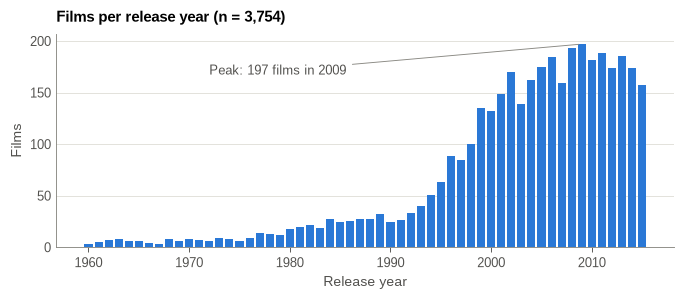

decade
1960s      56
1970s      92
1980s     241
1990s     645
2000s    1660
2010s    1060


In [25]:
# @title Figure 1: number of films per release year

per_year = df.groupby("release_year").size()
fig, ax = plt.subplots(figsize=(FIG_WIDTH, 2.8))
ax.bar(per_year.index, per_year.values, color=PRIMARY, width=0.8)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.set_title("Films per release year (n = 3,754)")
ax.set_xlabel("Release year")
ax.set_ylabel("Films")
peak = per_year.idxmax()
ax.annotate(f"Peak: {per_year.max()} films in {peak}", xy=(peak, per_year.max()),
            xytext=(1972, per_year.max() * 0.85), fontsize=8.5, color=INK_SECONDARY,
            arrowprops=dict(arrowstyle="-", color=AXIS, lw=0.6))
fig.tight_layout()
fig.savefig(drive_plots_path + "fig01_films_per_year.png", bbox_inches="tight")
plt.show()

print(df.groupby("decade").size().to_string())

**Remark** ✅ The number of films grows from a few per year in the 1960s to **150-200 per year after 2000** (peak: 197 in 2009). Almost three films in four (72%) were released after 2000. This reflects both the growth of film production and the **coverage bias** of TMDb, whose users document recent films better. Comparisons between decades must therefore use averages or medians, never totals.

> **Power BI (page Releases & Genres):** *Column chart* · Axis `Movies[Release Year]` · Values `[Total Movies]`.

## 9.2 Movies by genre (R2)

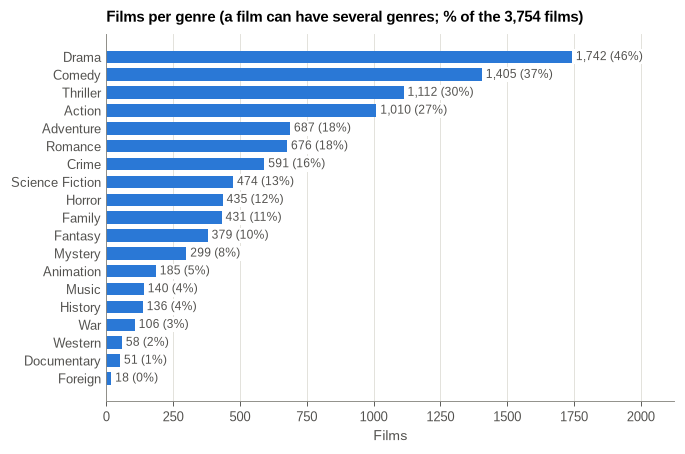

Genres per film: 2.65 on average


In [26]:
# @title Figure 2: films per genre

genre_counts = movie_genres["genre"].value_counts()
genre_counts = genre_counts[genre_counts >= 10].sort_values()
fig, ax = plt.subplots(figsize=(FIG_WIDTH, 4.2))
ax.barh(genre_counts.index, genre_counts.values, color=PRIMARY, height=0.7)
for y, val in enumerate(genre_counts.values):
    ax.text(val + 15, y, f"{val:,} ({val / len(df):.0%})", va="center", fontsize=8, color=INK_SECONDARY, bbox=dict(facecolor="white", edgecolor="none", pad=1.2))
ax.xaxis.grid(True)
ax.set_axisbelow(True)
ax.set_xlim(0, genre_counts.max() * 1.22)
ax.set_title("Films per genre (a film can have several genres; % of the 3,754 films)")
ax.set_xlabel("Films")
fig.tight_layout()
fig.savefig(drive_plots_path + "fig02_films_per_genre.png", bbox_inches="tight")
plt.show()
print(f"Genres per film: {movie_genres.groupby('movie_id').size().mean():.2f} on average")

**Remark** ✅ **Drama (46% of the films), Comedy (37%), Thriller (30%) and Action (27%)** dominate. A film carries 2.65 genres on average, so the bars add up to far more than 3,754 films; the dashboard must label this chart "films per genre", not "share of films".

> **Power BI (page Releases & Genres):** *Bar chart* · Axis `Movie Genres[Genre]` · Values `[Total Movies]` (counts distinct `Movie ID`) · sorted descending. Clicking a bar filters the whole page. The Home page shows the same counts as a word cloud.

## 9.3 Average rating across genres (R3)

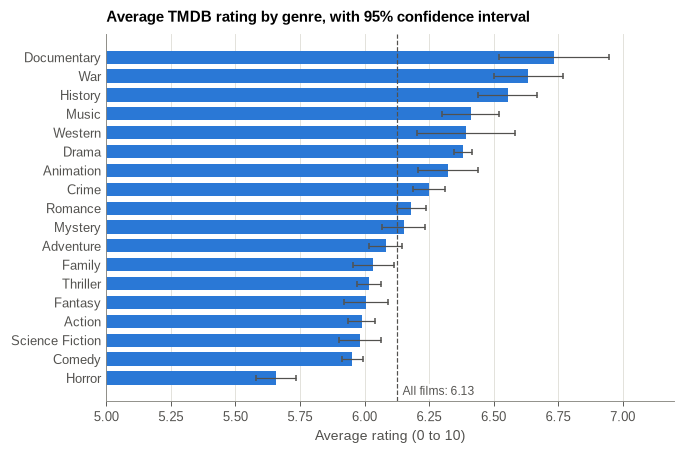

,mean,count,sem
genre,,,
Horror,5.66,435,0.04
Comedy,5.95,1405,0.02
Science Fiction,5.98,474,0.04
Action,5.99,1010,0.03
Fantasy,6.01,379,0.04
Thriller,6.02,1112,0.02
Family,6.03,431,0.04
Adventure,6.08,687,0.03
Mystery,6.15,299,0.04


In [27]:
# @title Figure 3: average rating by genre (genres with at least 50 films)

g = movie_genres.merge(df[["movie_id", "vote_average"]], on="movie_id")
genre_rating = g.groupby("genre")["vote_average"].agg(["mean", "count", "sem"])
genre_rating = genre_rating[genre_rating["count"] >= 50].sort_values("mean")
overall = df["vote_average"].mean()

fig, ax = plt.subplots(figsize=(FIG_WIDTH, 4.2))
ax.barh(genre_rating.index, genre_rating["mean"], xerr=1.96 * genre_rating["sem"],
        color=PRIMARY, height=0.7, error_kw=dict(ecolor=INK_SECONDARY, lw=0.8, capsize=2))
ax.axvline(overall, color=INK_SECONDARY, lw=0.8, ls="--")
ax.text(overall + 0.02, -0.9, f"All films: {overall:.2f}", fontsize=8, color=INK_SECONDARY, bbox=dict(facecolor="white", edgecolor="none", pad=1.2))
ax.set_xlim(5, 7.2)
ax.xaxis.grid(True)
ax.set_axisbelow(True)
ax.set_title("Average TMDB rating by genre, with 95% confidence interval")
ax.set_xlabel("Average rating (0 to 10)")
fig.tight_layout()
fig.savefig(drive_plots_path + "fig03_rating_by_genre.png", bbox_inches="tight")
plt.show()
genre_rating.round(2)

**Remark** ✅ Genres split into two groups. **Documentary (6.73), War (6.63), History (6.55), Music, Western and Drama (6.38)** are rated above the average of 6.13. **Horror (5.66)** is clearly the lowest, followed by Comedy, Science Fiction and Action (about 6.0). The spread is about one point on a ten-point scale: genre matters, but it does not decide a rating on its own. The confidence intervals show that the gaps between the extremes are real, while neighbouring genres are often not distinguishable (tested in section 10).

> **Power BI (page Releases & Genres):** *Bar chart* · Axis `Movie Genres[Genre]` · Values `[Avg Rating]` · sorted descending; a second chart gives `[Avg Rating]` by `Movies[Decade]`.

## 9.4 Relationship between budget and revenue (R4)

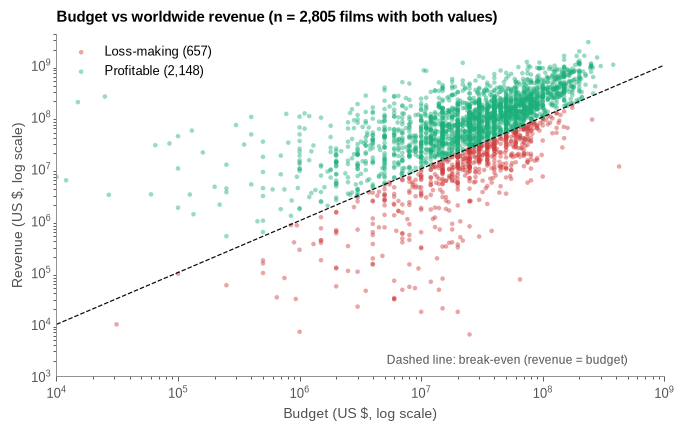

Spearman correlation budget-revenue: rho = 0.65 (p = 0.0e+00)


In [28]:
# @title Figure 4: budget vs revenue (log scales), with the break-even line

fig, ax = plt.subplots(figsize=(FIG_WIDTH, 4.0))
for label, color in [("Loss-making", CRITICAL), ("Profitable", GOOD)]:
    sub = fin[fin["profitable"] == label]
    ax.scatter(sub["budget"], sub["revenue"], s=9, alpha=0.45, color=color,
               edgecolors="none", label=f"{label} ({len(sub):,})")
lim = [1e4, 4e9]
ax.plot(lim, lim, color=INK, lw=0.8, ls="--")
ax.text(5e8, 2e3, "Dashed line: break-even (revenue = budget)", fontsize=8, color=INK_SECONDARY, ha="right", va="center", bbox=dict(facecolor="white", edgecolor="none", pad=1.2))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e4, 1e9)
ax.set_ylim(1e3, 4e9)
ax.set_title(f"Budget vs worldwide revenue (n = {len(fin):,} films with both values)")
ax.set_xlabel("Budget (US $, log scale)")
ax.set_ylabel("Revenue (US $, log scale)")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(drive_plots_path + "fig04_budget_vs_revenue.png", bbox_inches="tight")
plt.show()

rho, p = stats.spearmanr(fin["budget"], fin["revenue"])
print(f"Spearman correlation budget-revenue: rho = {rho:.2f} (p = {p:.1e})")

In [29]:
# @title Return on investment by budget class

fin_b = fin.assign(budget_class=pd.cut(fin["budget"], [0, 1e7, 3e7, 7e7, 1.5e8, 1e9],
                                       labels=["< $10M", "$10-30M", "$30-70M", "$70-150M", "> $150M"]))
roi_tab = fin_b.groupby("budget_class", observed=True).agg(
    films=("movie_id", "size"),
    median_revenue_M=("revenue", lambda s: s.median() / 1e6),
    median_roi=("roi", "median"),
    profitable_share=("profit", lambda s: (s > 0).mean()))
roi_tab.round(2)

,films,median_revenue_M,median_roi,profitable_share
budget_class,,,,
< $10M,568,13.91,3.39,0.76
$10-30M,926,41.76,2.17,0.74
$30-70M,793,95.00,1.98,0.75
$70-150M,424,237.53,2.29,0.82
> $150M,94,554.93,2.85,0.95


**Remark** ✅ Budget and revenue are **strongly related** (Spearman ρ = 0.65): bigger productions earn more in absolute terms. But a bigger budget does not guarantee a better **return**: the median ROI stays between 2.0 and 3.4 in every budget class and is even highest for small films (3.4x below $10 M), while the share of profitable films rises from about 75% below $70 M to 95% above $150 M, because blockbusters rarely fail completely. Below the dashed line, about one film in four (with known financials) does not recover its budget.

> **Power BI (page Box Office):** *Scatter chart* · Values `Movies[Title]` · X `[Budget ($M)]` · Y `[Revenue ($M)]` · *Trend line* on; a bar chart gives `[Median ROI]` by `Movies[Main Genre]`. The slicer *Financial result* isolates profitable or loss-making films.

## 9.5 Highest-grossing movies (R5)

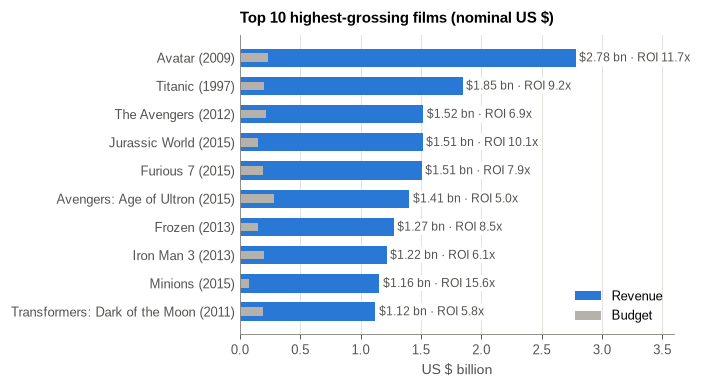

Top 10 in inflation-adjusted dollars (2010 $):
                     title  release_year
                    Avatar          2009
                 Star Wars          1977
                   Titanic          1997
              The Exorcist          1973
                      Jaws          1975
E.T. the Extra-Terrestrial          1982
                   The Net          1995
              The Avengers          2012
   The Empire Strikes Back          1980
            Jurassic World          2015


In [30]:
# @title Figure 5: top 10 films by worldwide revenue

top_gross = df.nlargest(10, "revenue").sort_values("revenue")
fig, ax = plt.subplots(figsize=(FIG_WIDTH, 3.6))
ax.barh(top_gross["title"] + " (" + top_gross["release_year"].astype(str) + ")",
        top_gross["revenue"] / 1e9, color=PRIMARY, height=0.65, label="Revenue")
ax.barh(top_gross["title"] + " (" + top_gross["release_year"].astype(str) + ")",
        top_gross["budget"] / 1e9, color=MUTED, height=0.3, label="Budget")
for y, (rev, roi) in enumerate(zip(top_gross["revenue"] / 1e9, top_gross["roi"])):
    ax.text(rev + 0.03, y, f"${rev:.2f} bn · ROI {roi:.1f}x", va="center", fontsize=8, color=INK_SECONDARY, bbox=dict(facecolor="white", edgecolor="none", pad=1.2))
ax.set_xlim(0, 3.6)
ax.xaxis.grid(True)
ax.set_axisbelow(True)
ax.set_title("Top 10 highest-grossing films (nominal US $)")
ax.set_xlabel("US $ billion")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(drive_plots_path + "fig05_top_grossing.png", bbox_inches="tight")
plt.show()

print("Top 10 in inflation-adjusted dollars (2010 $):")
print(df.nlargest(10, "revenue_adj")[["title", "release_year"]].to_string(index=False))

**Remark** ✅ **Avatar (2009, $2.78 bn), Titanic (1997, $1.85 bn) and The Avengers (2012, $1.52 bn)** lead in nominal dollars. The top 10 is made of **franchise and animation blockbusters**, all released after 2009 except *Titanic*, with budgets of $150-280 M (*Minions*: $74 M); each returns 5 to 16 times its budget. In 2010 dollars the ranking changes: older hits such as *Star Wars* (1977), *Titanic* and *The Exorcist* (1973) enter the top 10, which shows why a dashboard should offer the **adjusted** measure as an option.

> **Power BI (page Box Office):** *Bar chart* · Axis `Movies[Title]` · Values `[Revenue ($M)]` · Filter: *Top N = 10 by [Revenue ($M)]*. The Home page scrolls the 60 highest-grossing titles.

## 9.6 Highest-rated movies considering the vote count (R6)

In [31]:
# @title Why the raw rating is not enough

print("Top 5 by raw rating:")
print(df.nlargest(5, "vote_average")[["title", "vote_average", "vote_count"]].to_string(index=False))

Top 5 by raw rating:
                   title  vote_average  vote_count
The Shawshank Redemption           8.4        5754
        Guten Tag, Ramón           8.4          11
           The Godfather           8.3        3970
                Whiplash           8.2        2372
         The Dark Knight           8.1        8432


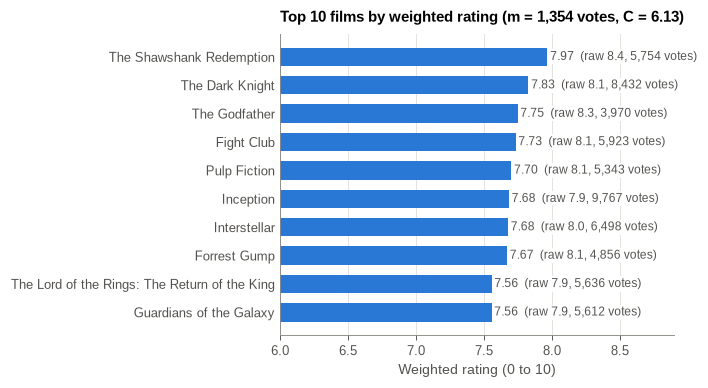

In [32]:
# @title Figure 6: top 10 films by weighted rating

top_rated = df.nlargest(10, "weighted_rating").sort_values("weighted_rating")
fig, ax = plt.subplots(figsize=(FIG_WIDTH, 3.6))
ax.barh(top_rated["title"], top_rated["weighted_rating"], color=PRIMARY, height=0.65)
for y, (wr, r, vcount) in enumerate(zip(top_rated["weighted_rating"], top_rated["vote_average"], top_rated["vote_count"])):
    ax.text(wr + 0.02, y, f"{wr:.2f}  (raw {r:.1f}, {vcount:,} votes)", va="center", fontsize=8, color=INK_SECONDARY, bbox=dict(facecolor="white", edgecolor="none", pad=1.2))
ax.set_xlim(6, 8.9)
ax.xaxis.grid(True)
ax.set_axisbelow(True)
ax.set_title(f"Top 10 films by weighted rating (m = {m:,.0f} votes, C = {C:.2f})")
ax.set_xlabel("Weighted rating (0 to 10)")
fig.tight_layout()
fig.savefig(drive_plots_path + "fig06_top_rated.png", bbox_inches="tight")
plt.show()

**Remark** ✅ On the raw rating, an obscure film rated 8.4 by **11 users** ties with *The Shawshank Redemption* (8.4 from **5,754 users**). The weighted rating pulls films with few votes towards the average of 6.13 and gives a robust ranking: **The Shawshank Redemption, The Dark Knight, The Godfather, Fight Club, Pulp Fiction, Inception, Interstellar, Forrest Gump**. All have thousands of votes; quality and audience size go together at the top.

> **Power BI (page Ratings & Runtime):** *Table* · columns `Title`, `Release Year`, `Rating`, `Votes`, `Weighted Rating` · sorted by `Weighted Rating` · *Top N = 10 by [Weighted Score]*. `Weighted Rating` is a DAX calculated column with the same formula (C and m computed on the 3,754 films).

## 9.7 Revenue and ratings over the years (R7)

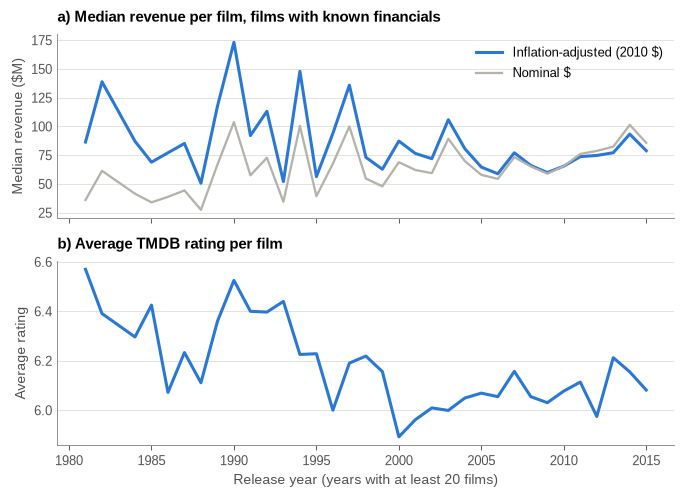

        films  avg_rating  median_rev_adj_M
decade                                     
1960s      56        6.61            235.93
1970s      92        6.66            136.47
1980s     241        6.33             84.05
1990s     645        6.22             80.91
2000s    1660        6.03             67.82
2010s    1060        6.10             66.82


In [33]:
# @title Figure 7: median revenue (2010 $) and average rating per year

yearly = df.groupby("release_year").agg(films=("movie_id", "size"), rating=("vote_average", "mean"))
yearly_fin = fin.groupby("release_year").agg(films_fin=("movie_id", "size"),
                                             rev_adj=("revenue_adj", "median"), rev_nom=("revenue", "median"))
yearly = yearly.join(yearly_fin)
y = yearly[yearly["films"] >= 20]          # years with enough films for a stable value

fig, axes = plt.subplots(2, 1, figsize=(FIG_WIDTH, 4.6), sharex=True)
axes[0].plot(y.index, y["rev_adj"] / 1e6, color=PRIMARY, lw=2, label="Inflation-adjusted (2010 $)")
axes[0].plot(y.index, y["rev_nom"] / 1e6, color=MUTED, lw=1.5, label="Nominal $")
axes[0].set_ylabel("Median revenue ($M)")
axes[0].set_title("a) Median revenue per film, films with known financials")
axes[0].legend(loc="upper right")
axes[1].plot(y.index, y["rating"], color=PRIMARY, lw=2)
axes[1].set_ylabel("Average rating")
axes[1].set_title("b) Average TMDB rating per film")
axes[1].set_xlabel("Release year (years with at least 20 films)")
for ax in axes:
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(drive_plots_path + "fig07_trends.png", bbox_inches="tight")
plt.show()

print(df.groupby("decade").agg(films=("movie_id", "size"), avg_rating=("vote_average", "mean"),
                               median_rev_adj_M=("revenue_adj", lambda s: s.median() / 1e6)).round(2).to_string())

**Remark** ✅ Two trends stand out.
- **Revenue:** in adjusted dollars, the median film falls from about $136 M in the 1970s to $81-84 M in the 1980s-1990s and $67-68 M after 2000; nominal revenues grow mostly because of inflation. The increase of the totals comes from **more films** and from a few **record blockbusters**, not from a richer typical film.
- **Ratings:** the average rating **declines slowly** from about 6.6-6.7 for films of the 1960s-1970s to about 6.0-6.1 after 2000 (Spearman ρ = −0.09 with the year, small but significant). This is partly a **survivorship effect**: the old films kept in the database are the classics people still watch and rate, whereas recent years include every release.

> **Power BI:** two separate *Line charts* (not one chart with two axes) · Axis `Movies[Release Year]` · Values `[Median Revenue Adj ($M) 20+]` (page Box Office) and `[Avg Rating 20+]` (page Ratings & Runtime): both measures are blank for years with fewer than 20 films, as in the figure above.

## 9.8 Runtime vs ratings and revenue (R8)

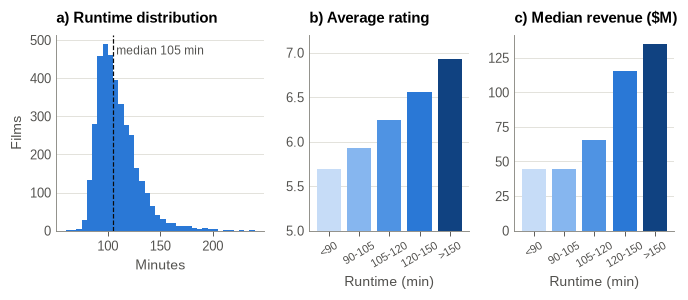

,films,rating,median_revenue_M
runtime_class,,,
< 90 min,562,5.69,44.46
90-105 min,1379,5.93,44.83
105-120 min,983,6.24,65.75
120-150 min,695,6.56,115.23
> 150 min,133,6.93,134.79


In [34]:
# @title Figure 8: runtime distribution and runtime classes

rt = df.groupby("runtime_class", observed=True).agg(
    films=("movie_id", "size"), rating=("vote_average", "mean"))
rt_fin = fin.groupby("runtime_class", observed=True)["revenue"].median() / 1e6
rt["median_revenue_M"] = rt_fin

fig, axes = plt.subplots(1, 3, figsize=(FIG_WIDTH, 2.8), gridspec_kw={"width_ratios": [1.3, 1, 1]})
axes[0].hist(df["runtime"].dropna(), bins=np.arange(60, 241, 5), color=PRIMARY)
axes[0].axvline(df["runtime"].median(), color=INK, lw=0.8, ls="--")
axes[0].text(df["runtime"].median() + 3, axes[0].get_ylim()[1] * 0.9 if axes[0].get_ylim()[1] else 1,
             f"median {df['runtime'].median():.0f} min", fontsize=8, color=INK_SECONDARY)
axes[0].set_title("a) Runtime distribution")
axes[0].set_xlabel("Minutes")
axes[0].set_ylabel("Films")
labels = ["<90", "90-105", "105-120", "120-150", ">150"]
axes[1].bar(labels, rt["rating"], color=RAMP)
axes[1].set_ylim(5, 7.2)
axes[1].set_title("b) Average rating")
axes[1].set_xlabel("Runtime (min)")
axes[2].bar(labels, rt["median_revenue_M"], color=RAMP)
axes[2].set_title("c) Median revenue ($M)")
axes[2].set_xlabel("Runtime (min)")
for ax in axes[1:]:
    ax.tick_params(axis="x", labelsize=7.5, rotation=30)
for ax in axes:
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(drive_plots_path + "fig08_runtime.png", bbox_inches="tight")
plt.show()
rt.round(2)

**Remark** ✅ Most films last **95 to 118 minutes** (median 105). Length is clearly associated with both faces of success:
- **Ratings rise steadily with length**, from 5.69 for films under 90 minutes to **6.93 for films over 2 h 30** (Spearman ρ = 0.38 between runtime and rating, the strongest numeric link with rating in the data).
- **Median revenue triples** from about $45 M for films under 1 h 45 to about $135 M for films over 2 h 30 (ρ = 0.25).

This is an **association, not a recipe**: long films are more often prestige dramas, epics and franchise blockbusters with bigger budgets. Making a film longer would not by itself make it better.

> **Power BI (page Ratings & Runtime):** two *Column charts* by `Movies[Runtime Class]` (sorted by `Runtime Class Order`, class *Unknown* excluded) with `[Avg Rating]` and `[Median Revenue ($M)]`; the slicer *Runtime class* filters every page.

## 9.9 Complement: the people behind the films (from the supplied credits)

The supplied file describes the people of each film. It answers a question the other analyses cannot: **which directors and actors are associated with commercial and critical success?**

In [35]:
# @title Top directors (at least 5 films with known financials)

dir_fin = movie_directors.merge(fin[["movie_id", "revenue", "vote_average"]], on="movie_id")
top_dirs = (dir_fin.groupby("director")
            .agg(films=("movie_id", "size"), total_revenue_bn=("revenue", lambda s: s.sum() / 1e9),
                 avg_rating=("vote_average", "mean"))
            .query("films >= 5").nlargest(10, "total_revenue_bn").round(2))
top_dirs

,films,total_revenue_bn,avg_rating
director,,,
Steven Spielberg,26,8.96,6.85
Peter Jackson,9,6.49,7.19
James Cameron,7,5.82,7.16
Michael Bay,11,4.92,6.33
Christopher Nolan,8,4.17,7.64
Chris Columbus,9,3.73,6.61
Robert Zemeckis,12,3.44,6.82
Tim Burton,14,3.38,6.60
George Lucas,5,3.31,6.82


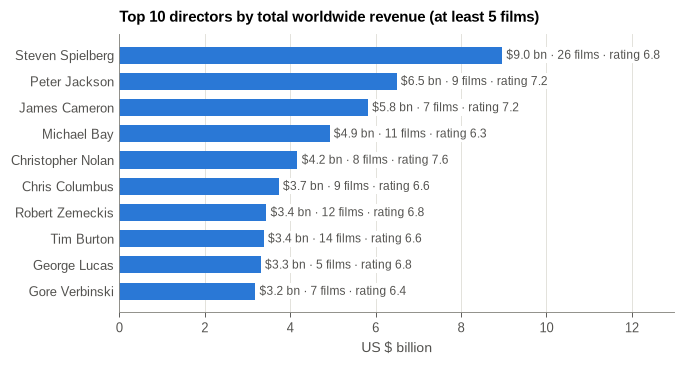

In [36]:
# @title Figure 9: top 10 directors by total revenue

td = top_dirs.sort_values("total_revenue_bn")
fig, ax = plt.subplots(figsize=(FIG_WIDTH, 3.4))
ax.barh(td.index, td["total_revenue_bn"], color=PRIMARY, height=0.65)
for y, (rev, n, r) in enumerate(zip(td["total_revenue_bn"], td["films"], td["avg_rating"])):
    ax.text(rev + 0.1, y, f"${rev:.1f} bn · {n} films · rating {r:.1f}", va="center", fontsize=8, color=INK_SECONDARY, bbox=dict(facecolor="white", edgecolor="none", pad=1.2))
ax.set_xlim(0, td["total_revenue_bn"].max() * 1.45)
ax.xaxis.grid(True)
ax.set_axisbelow(True)
ax.set_title("Top 10 directors by total worldwide revenue (at least 5 films)")
ax.set_xlabel("US $ billion")
fig.tight_layout()
fig.savefig(drive_plots_path + "fig09_top_directors.png", bbox_inches="tight")
plt.show()

In [37]:
# @title Most frequent lead and supporting actors

top_actors = (movie_cast.merge(df[["movie_id", "vote_average"]], on="movie_id")
              .groupby("actor").agg(films=("movie_id", "size"), avg_rating=("vote_average", "mean"))
              .nlargest(10, "films").round(2))
top_actors

,films,avg_rating
actor,,
Robert De Niro,51,6.38
Samuel L. Jackson,41,6.20
Bruce Willis,39,6.14
Matt Damon,35,6.49
Nicolas Cage,35,5.93
Morgan Freeman,32,6.42
Brad Pitt,31,6.76
Johnny Depp,31,6.48
Mark Wahlberg,31,6.22


**Remark** ✅ **Steven Spielberg ($9.0 bn, 26 films), Peter Jackson and James Cameron** head the directors by total revenue. Jackson, Cameron and above all **Christopher Nolan (7.64)** combine box office with high ratings, whereas Michael Bay's films earn a lot with an average rating of 6.3. The most frequent actors in the top-5 billing are actors with long careers (Robert De Niro, 51 films; Samuel L. Jackson, 41; Bruce Willis, 39). These rankings add a **people** dimension to the dashboard: page People.

> **Power BI (page People):** *Bar chart* Axis `Movie Directors[Director]` · Values `[Total Revenue ($bn)]` · Top N = 10; *Bar chart* `Movie Cast[Actor]` by `[Total Movies]` (three first-billed actors, the leading roles: Robert De Niro 44 films); *Bar chart* of the best directors by `[Director Score (3+ films)]`, the mean weighted rating of directors with at least three films (Christopher Nolan 7.28).

<a name="statistical-tests"></a>
# 10. Statistical Tests

Ratings, revenues and budgets are skewed, so the tests are **non-parametric**: Spearman rank correlation for pairs of numeric variables, Kruskal-Wallis for differences between groups.

In [38]:
# @title Rank correlations between the success factors

pairs = [("budget", "revenue", fin), ("runtime", "vote_average", df), ("runtime", "revenue", fin),
         ("release_year", "vote_average", df), ("vote_count", "vote_average", df),
         ("budget", "vote_average", fin), ("vote_average", "revenue", fin)]
rows = []
for a, b, data in pairs:
    d = data[[a, b]].dropna()
    rho, p = stats.spearmanr(d[a], d[b])
    strength = "strong" if abs(rho) >= 0.5 else "moderate" if abs(rho) >= 0.3 else "weak" if abs(rho) >= 0.1 else "negligible"
    rows.append((f"{a} vs {b}", len(d), round(rho, 2), f"{p:.1e}", strength))
corr_tab = pd.DataFrame(rows, columns=["Pair", "n", "Spearman rho", "p-value", "Strength"])
corr_tab.to_csv(drive_results_path + "correlations.csv", index=False)
corr_tab

,Pair,n,Spearman rho,p-value,Strength
0,budget vs revenue,2805,0.65,0.0e+00,strong
1,runtime vs vote_average,3752,0.38,7.6e-132,moderate
2,runtime vs revenue,2805,0.25,8.2e-40,weak
3,release_year vs vote_average,3754,-0.09,1.0e-07,negligible
4,vote_count vs vote_average,3754,0.39,2.0e-133,moderate
5,budget vs vote_average,2805,-0.08,3.3e-05,negligible
6,vote_average vs revenue,2805,0.19,8.9e-24,weak


In [39]:
# @title Kruskal-Wallis: do genres differ in rating? Does runtime class matter?

big = genre_rating.index.tolist()
groups = [g.loc[g["genre"] == x, "vote_average"] for x in big]
H, p = stats.kruskal(*groups)
print(f"Rating by genre (genres with >= 50 films): H = {H:.1f}, p = {p:.1e}")

groups_rt = [df.loc[df["runtime_class"] == c, "vote_average"] for c in df["runtime_class"].cat.categories]
H2, p2 = stats.kruskal(*groups_rt)
print(f"Rating by runtime class: H = {H2:.1f}, p = {p2:.1e}")

d1 = g.loc[g["genre"] == "Drama", "vote_average"]
d2 = g.loc[g["genre"] == "Horror", "vote_average"]
U, p3 = stats.mannwhitneyu(d1, d2)
print(f"Drama vs Horror: Mann-Whitney U = {U:,.0f}, p = {p3:.1e}")

Rating by genre (genres with >= 50 films): H = 625.7, p = 5.2e-122
Rating by runtime class: H = 556.9, p = 3.2e-119
Drama vs Horror: Mann-Whitney U = 566,816, p = 7.1e-58


**Remark** ✅
- **Budget ↔ revenue is the only strong link** (ρ = 0.65).
- **Runtime ↔ rating is moderate** (ρ = 0.38) and **runtime ↔ revenue weak** (ρ = 0.25); **votes ↔ rating** is also moderate: the films people rate most are the films they like.
- **Budget ↔ rating is close to zero**: money buys revenue, not acclaim.
- Genre and runtime class both have a significant effect on ratings (Kruskal-Wallis p ≪ 0.001).

With 2,800 to 3,750 films, even small correlations are "significant": the **strength** column, not the p-value, says what matters.

<a name="powerbi"></a>
# 11. The Power BI Dashboard (requirement R10)

The dashboard is delivered as **`powerbi/Movie_Analytics_Dashboard.pbix`** (data loaded, opens directly) and as its template **`powerbi/Movie_Analytics_Dashboard.pbit`**. It does not import the tables of this notebook: it loads the **supplied file itself** and rebuilds the same tables in **Power Query**, so that the path from `tmdb_5000_credits.csv` to every visual can be read in Power BI (Home → Transform data → Applied Steps). The full M code is in `powerbi/PowerQuery_pipeline.m`, the DAX in `powerbi/DAX_measures.dax`.

## 11.1 Data pipeline

| Step | Power Query | This notebook |
|---|---|---|
| Read Source 1, the supplied file | query `Credits Raw` | section 5 |
| Read Source 2, the enrichment; remove the duplicated `id` | query `TMDb Movies Raw` | sections 5 and 6 |
| Inner join `movie_id = id` (3,754 films) | `Movies`: *Merged Queries* | section 7, step 1 |
| 0 → null for budget, revenue, runtime | `Movies`: *Zero As Unknown* | section 7, step 2 |
| Director, lead actor, three first-billed actors from the JSON | `Movies`, `Movie Directors`, `Movie Cast` | section 7, step 5 |
| Decade, main genre, runtime class, profit, ROI, result | `Movies` | section 7, step 3 |
| Weighted rating (m = 1,354) | DAX calculated column `Movies[Weighted Rating]` | section 7, step 4 |

The **Table view** of Power BI lists six tables: `tmdb_5000_credits` (the supplied file as received, with the number of cast and crew members of each film and a flag *In Analysis*), `TMDb Movies` (the enrichment), and the four analysis tables `Movies`, `Movie Genres`, `Movie Directors`, `Movie Cast`. The cast and crew of the supplied file are JSON texts (up to several hundred people per film): Power BI cannot filter or rank inside a text, so they are unpacked into one row per person and film.

Source 1: 4,803 films | Source 2: 10,865 films | Movies: 3,754 | Genres: 9,939 | Directors: 4,016 | Cast: 11,153


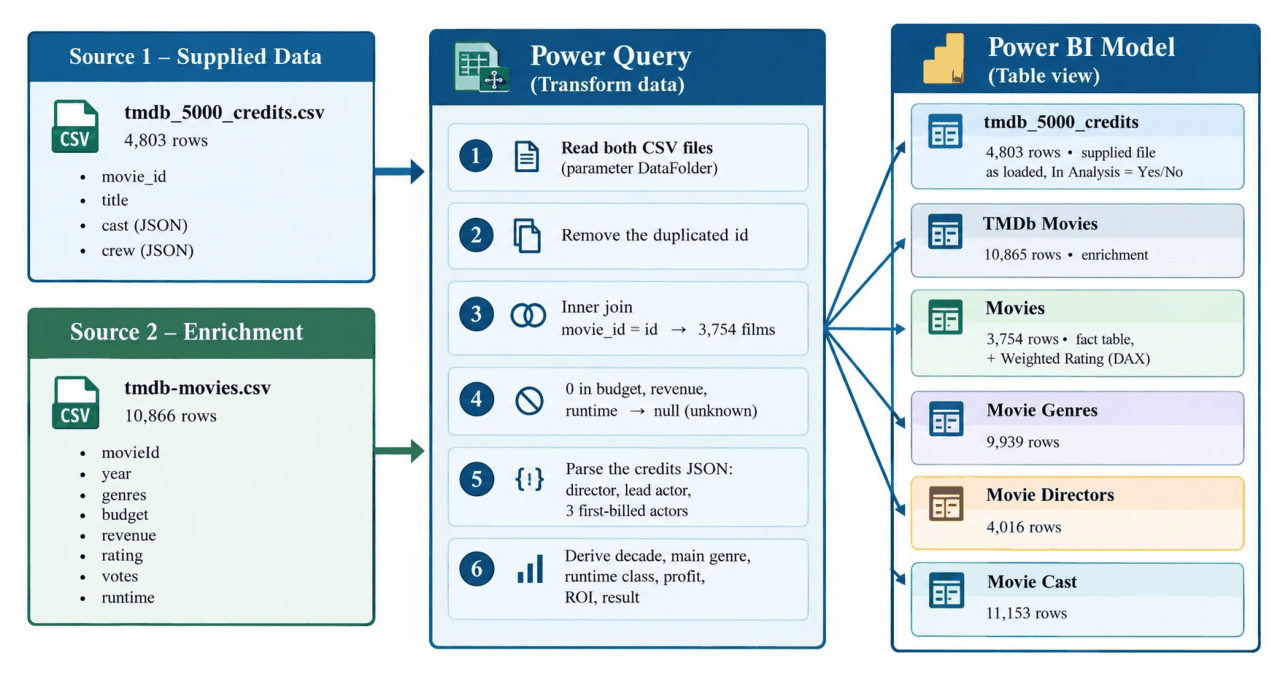

In [40]:
# @title Figure 10: data pipeline of the dashboard (diagram)

n_cast3 = int((movie_cast["billing_order"] < 3).sum())   # rows of the Power BI table Movie Cast
print(f"Source 1: {len(credits_raw):,} films | Source 2: {movies_raw['id'].nunique():,} films | "
      f"Movies: {len(movies):,} | Genres: {len(movie_genres):,} | Directors: {len(movie_directors):,} | Cast: {n_cast3:,}")

pipeline = plt.imread(drive_plots_path + "fig10_data_pipeline.png")
fig, ax = plt.subplots(figsize=(12, 6.3))
ax.imshow(pipeline)
ax.axis("off")
fig.tight_layout()
plt.show()

In [41]:
# @title Expected values of the Data Pipeline page (check after opening the dashboard)

n_cast = credits_raw["cast"].map(lambda s: len(json.loads(s)))
n_crew = credits_raw["crew"].map(lambda s: len(json.loads(s)))
check = pd.DataFrame({
    "Card / table": ["Films in Supplied File", "Films Analysed", "Match Rate", "Cast Entries", "Crew Entries",
                     "Movie Genres rows", "Movie Directors rows", "Movie Cast rows (3 first-billed)"],
    "Expected value": [f"{len(credits_raw):,}", f"{len(movies):,}", f"{len(movies) / len(credits_raw):.1%}",
                       f"{n_cast.sum():,}", f"{n_crew.sum():,}", f"{len(movie_genres):,}",
                       f"{len(movie_directors):,}", f"{n_cast3:,}"]})
check

,Card / table,Expected value
0,Films in Supplied File,"4,803"
1,Films Analysed,"3,754"
2,Match Rate,78.2%
3,Cast Entries,"106,257"
4,Crew Entries,"129,581"
5,Movie Genres rows,"9,939"
6,Movie Directors rows,"4,016"
7,Movie Cast rows (3 first-billed),"11,153"


## 11.2 Data model and measures

- `Movie Genres`, `Movie Directors` and `Movie Cast` are linked to `Movies[Movie ID]` (many to one, cross filter **Both**), so that a genre, director or actor selection filters the films; `tmdb_5000_credits` and `TMDb Movies` are linked to `Movies` on the identifier to show the lineage.
- `Movies[Runtime Class]` is sorted by `Runtime Class Order`.
- **22 DAX measures**: the KPIs of section 8 (`Total Movies`, `Total Revenue ($bn)`, `Total Budget ($bn)`, `Median ROI`, `% Profitable`, `Avg Rating`, `Avg Runtime (min)`, `Total Votes`...), the guarded measures `Avg Rating 20+`, `Median Revenue Adj ($M) 20+` and `Director Score (3+ films)`, and five measures describing the supplied file (`Films in Supplied File`, `Films Analysed`, `Match Rate`, `Cast Entries`, `Crew Entries`).

## 11.3 Pages

Style of the OTT reference dashboard: dark navy background, light-blue accents, glowing header with a page navigator, rounded frames, word cloud and scrolling text. Four slicers synchronised across the analysis pages: release year, genre, runtime class, financial result.

| Page | Visuals (requirement) |
|---|---|
| **1. Home** | 8 KPI cards (R9) · word cloud of genres · 3 clickable tiles to the analysis pages · scrolling list of the top-grossing titles |
| **2. Releases & Genres** | films per year (R1) · films by genre (R2) · average rating by genre and by decade (R3) |
| **3. Box Office** | budget vs revenue scatter with trend line (R4) · Top 10 grossing (R5) · median adjusted revenue per year, 20+ films (R7) · median ROI by main genre |
| **4. Ratings & Runtime** | Top 10 by weighted rating (R6) · gauge of the average rating · rating and median revenue by runtime class (R8) · average rating per year, 20+ films (R7) |
| **5. People** | Top 10 directors by revenue · Top 10 actors (3 first-billed) · best directors, 3+ films |
| **6. Insights** | the 10 insights of section 12 (R11) |
| **7. Data Pipeline** | the supplied file as loaded: 5 cards, donut *In Analysis*, table `tmdb_5000_credits`, the pipeline steps |

**Interactivity:** cross-filtering between visuals, synchronised slicers, Top N filters that follow the slicers, page navigator and clickable tiles, tooltips on every visual.

<a name="insights"></a>
# 12. Insights & Trends (requirement R11)

These are the messages the dashboard must tell, in the order of the story.

| # | Insight | Evidence | Dashboard page |
|---|---|---|---|
| 1 | **Production exploded after 2000**: 72% of the films were released after 2000, with 150-200 films a year. | Fig. 1 | Releases & Genres |
| 2 | **Drama, Comedy, Thriller and Action dominate** the catalogue; a film has 2.65 genres on average. | Fig. 2 | Releases & Genres |
| 3 | **Genre shapes the rating**: Documentary, War and History are rated about 0.5 point above average, Horror about 0.5 point below. | Fig. 3, Kruskal-Wallis | Releases & Genres |
| 4 | **Money buys revenue, not acclaim**: budget and revenue are strongly linked (ρ = 0.65), budget and rating are not. | Fig. 4, Table 10 | Box Office |
| 5 | **The typical film is profitable**: median ROI 2.3x, 77% of films with known financials recover their budget; but one in four does not. | KPIs | Box Office |
| 6 | **The box office is ruled by franchise blockbusters** released after 2009 (Avatar, The Avengers, Jurassic World...), each returning 5 to 16 times its budget; in adjusted dollars, classics (Star Wars, Titanic) still rival them. | Fig. 5 | Box Office |
| 7 | **The best films are also widely seen**: once the vote count is considered, the top 10 are all films with thousands of votes (Shawshank Redemption, The Dark Knight, The Godfather). | Fig. 6 | Ratings & Runtime |
| 8 | **The typical film is not richer than 30 years ago** in adjusted dollars, and average ratings drift down slightly over time (survivorship of old classics). | Fig. 7 | Box Office / Ratings & Runtime |
| 9 | **Longer films are better rated and earn more**: from 5.7 (< 90 min) to 6.9 (> 150 min), median revenue × 3; an association driven by the type of film, not a rule. | Fig. 8 | Ratings & Runtime |
| 10 | **A few directors concentrate the box office** (Spielberg, Jackson, Cameron); Nolan combines revenue and the best average rating (7.6). | Fig. 9 | People |

## Recommendations for a studio

1. **Use budget as a revenue lever, not as a quality lever**: quality (rating) depends on genre, format and talent, not on spending.
2. **Diversify the slate**: lower-rated genres (Horror, Comedy) are frequent and can be profitable, but critical reputation is built in Drama, History and War.
3. **Judge films on ROI and adjusted dollars**, never on nominal revenue alone.
4. **Rank quality with the weighted rating**, and show the vote count next to every rating in internal reporting.

In [42]:
# @title Save the main result tables

genre_rating.round(3).to_csv(drive_results_path + "rating_by_genre.csv")
roi_tab.round(3).to_csv(drive_results_path + "roi_by_budget_class.csv")
rt.round(3).to_csv(drive_results_path + "runtime_classes.csv")
df.nlargest(10, "revenue")[["title", "release_year", "budget", "revenue", "roi"]].to_csv(
    drive_results_path + "top10_grossing.csv", index=False)
df.nlargest(10, "weighted_rating")[["title", "release_year", "vote_average", "vote_count", "weighted_rating"]].to_csv(
    drive_results_path + "top10_weighted_rating.csv", index=False)
top_dirs.to_csv(drive_results_path + "top10_directors.csv")
print(sorted(os.listdir(drive_results_path)))

['correlations.csv', 'kpis.csv', 'rating_by_genre.csv', 'roi_by_budget_class.csv', 'runtime_classes.csv', 'top10_directors.csv', 'top10_grossing.csv', 'top10_weighted_rating.csv']


<a name="limitations"></a>
# 13. Limitations & Future Works

**Limitations**
- **Coverage:** 3,754 of the 4,803 supplied films (78.2%) are analysed; 2016-2017 releases are missing because the attribute file stops in 2015. With the companion file `tmdb_5000_movies.csv` of the same Kaggle dataset, the notebook would cover all 4,803 films by changing only the loading cell.
- **Financial data** are declared and incomplete (2,805 films with both budget and revenue); smaller productions are under-represented, which flatters the profitability KPI.
- **Ratings** come from TMDb users; they are not critics' scores and they over-represent popular films.
- **Correlations are not causes:** runtime, budget and genre are linked to one another.

**Future works**
- Join `tmdb_5000_movies.csv` (or the TMDb API) to cover 2016-2017.
- Add marketing spend, release window and country of production.
- Model revenue and rating jointly (multiple regression) to separate the effects of budget, genre, runtime and talent.

<a name="references"></a>
# 14. References

1. The Movie Database (TMDb). *TMDB 5000 Movie Dataset*, Kaggle, 2017: origin of the supplied file `tmdb_5000_credits.csv` (Source 1). https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata
2. TMDb Movies dataset (10,866 films, 1960-2015), public copy, Source 2 (enrichment): https://github.com/yinghaoz1/tmdb-movie-dataset-analysis
3. Gebru, T. et al. (2021). Datasheets for Datasets. *Communications of the ACM*, 64(12), 86-92.
4. IMDb. *Weighted rating formula used for the Top 250* (Bayesian average). https://help.imdb.com/article/imdb/track-movies-tv/ratings-faq/G67Y87TFYYP6TWAV
5. Microsoft. *Power BI documentation: Power Query M reference, DAX function reference*. https://learn.microsoft.com/power-bi/